# Stock Movement Prediction: Baseline vs. LSTM

**Objective:** Predict whether tomorrow's AAPL closing price will be higher than today's (Up = 1, Down = 0) using the last 30 days of data.

**Models:** Logistic Regression · Random Forest · LSTM

**Design principles:**
- Time-ordered train/test split — no data leakage
- Scaler fitted on training data only
- All three models evaluated on the same test window

> For full theoretical background on every model and metric, see `Theoritical Background.md`.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

2026-03-29 14:58:07.735297: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1. Load Data

In [2]:
DATA_PATH    = "../data/financial_forecasting_dataset.csv"
RESULTS_PATH = "../results"

df = pd.read_csv(DATA_PATH)
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,GDP (%),Inflation (%),Interest Rate (%),Unemployment (%),Market Stress Level,Event Flag
0,2020-01-01,AAPL,215.19,215.61,213.25,213.62,13046059,2.14,2.30,1.35,3.58,0.26,0
1,2020-01-02,AAPL,216.79,221.37,215.51,217.65,8515186,2.73,1.93,1.52,2.86,0.18,0
2,2020-01-03,AAPL,209.71,210.58,207.90,208.23,13704556,1.73,2.00,1.44,4.31,0.06,0
3,2020-01-04,AAPL,213.80,216.45,210.78,212.32,6833411,1.77,2.32,1.59,2.59,0.35,0
4,2020-01-05,AAPL,209.33,211.16,206.23,210.03,11862560,1.90,1.81,1.12,4.88,0.27,0


## 2. Clean

In [3]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

if 'Ticker' in df.columns:
    df = df[df['Ticker'] == 'AAPL'].copy()

print(df.shape)
print(df.isna().sum())

(500, 13)
Date                   0
Ticker                 0
Open                   0
High                   0
Low                    0
Close                  0
Volume                 0
GDP (%)                0
Inflation (%)          0
Interest Rate (%)      0
Unemployment (%)       0
Market Stress Level    0
Event Flag             0
dtype: int64


## 3. Exploratory Data Analysis

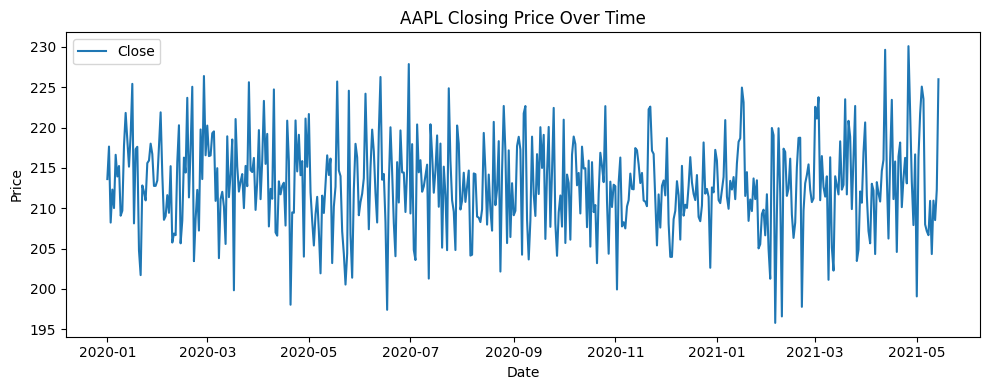

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Close'], label='Close')
plt.title('AAPL Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Feature Engineering

| Feature | Formula | Captures |
|---|---|---|
| `lag_1` … `lag_30` | `Close.shift(k)` | 30-day price history |
| `return_1d` | `(Close - Close_{t-1}) / Close_{t-1}` | Daily momentum |
| `rolling_mean_5` | 5-day moving average | Short-term trend |
| `rolling_std_5` | 5-day rolling std dev | Short-term volatility |

In [5]:
# Binary target: 1 if tomorrow's close > today's close
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 30 lag features
for k in range(1, 31):
    df[f'lag_{k}'] = df['Close'].shift(k)

# Technical indicators
df['return_1d']      = df['Close'].pct_change()
df['rolling_mean_5'] = df['Close'].rolling(5).mean()
df['rolling_std_5']  = df['Close'].rolling(5).std()

# Drop NaN rows introduced by shifting and rolling
df_model = df.dropna().copy()

lag_cols  = [f'lag_{k}' for k in range(1, 31)]
feat_cols = lag_cols + ['return_1d', 'rolling_mean_5', 'rolling_std_5']

X = df_model[feat_cols].values   # shape: (N, 33)
y = df_model['Target'].values    # shape: (N,)

# Time-based 80/20 split
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Class balance (test) — Up: {y_test.sum()}, Down: {(y_test==0).sum()}")

Train: (376, 33)  |  Test: (94, 33)
Class balance (test) — Up: 48, Down: 46


## 5. Baseline Models

### 5.1 Logistic Regression

Scaling is required because LR optimises via gradient descent and is sensitive to feature magnitude differences across the 33 features.

In [6]:
scaler     = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)  # fit + transform on train
X_test_lr  = scaler.transform(X_test)       # transform only — avoids leakage

lr = LogisticRegression(max_iter=500)
lr.fit(X_train_lr, y_train)
lr_pred = lr.predict(X_test_lr)

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)

print(f"Logistic Regression — Acc: {lr_acc:.4f}  Prec: {lr_prec:.4f}  Rec: {lr_rec:.4f}")
print(classification_report(y_test, lr_pred))

Logistic Regression — Acc: 0.6489  Prec: 0.6829  Rec: 0.5833
              precision    recall  f1-score   support

           0       0.62      0.72      0.67        46
           1       0.68      0.58      0.63        48

    accuracy                           0.65        94
   macro avg       0.65      0.65      0.65        94
weighted avg       0.65      0.65      0.65        94



### 5.2 Random Forest

In [7]:
# No scaling needed — tree splits are threshold-based, not magnitude-sensitive
rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)

print(f"Random Forest — Acc: {rf_acc:.4f}  Prec: {rf_prec:.4f}  Rec: {rf_rec:.4f}")
print(classification_report(y_test, rf_pred))

Random Forest — Acc: 0.6596  Prec: 0.6905  Rec: 0.6042
              precision    recall  f1-score   support

           0       0.63      0.72      0.67        46
           1       0.69      0.60      0.64        48

    accuracy                           0.66        94
   macro avg       0.66      0.66      0.66        94
weighted avg       0.66      0.66      0.66        94



### 5.3 Confusion Matrices

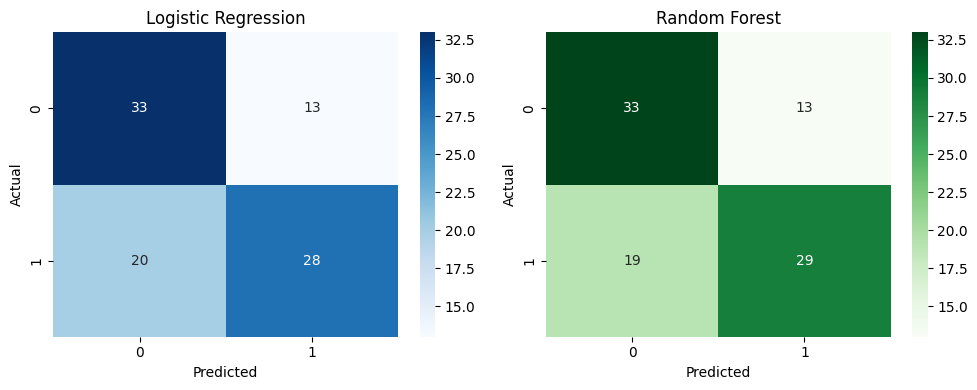

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d',
            ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d',
            ax=axes[1], cmap='Greens')
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 6. LSTM (Advanced Model)

LSTM reads the data as a temporal sequence `(samples, timesteps=30, features=33)` rather than a flat vector. This allows it to learn patterns that span across consecutive trading days.

Key differences from the baseline models:
- Input is a 3D tensor built from a sliding 30-day window
- All 33 features are used (same as LR and RF)
- MinMaxScaler compresses inputs to [0, 1] to keep activations in non-saturating range
- Dropout layers regularise the network to prevent memorisation

In [9]:
seq_len   = 30
n_feats   = len(feat_cols)   # 33

# Build sliding-window sequences — X[i] predicts y[i]
X_seq, y_seq = [], []
for i in range(seq_len, len(X)):
    X_seq.append(X[i - seq_len : i])   # shape: (30, 33)
    y_seq.append(y[i])                  # scalar target

X_seq = np.array(X_seq)   # (N-30, 30, 33)
y_seq = np.array(y_seq)   # (N-30,)

print(f"X_seq: {X_seq.shape}  |  y_seq: {y_seq.shape}")
print(f"Class balance — Up: {y_seq.sum()}, Down: {(y_seq==0).sum()}")

X_seq: (440, 30, 33)  |  y_seq: (440,)
Class balance — Up: 216, Down: 224


In [10]:
# Time-based split
split_seq = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]

# Scale: flatten to 2D → fit → reshape back to 3D
n_tr, n_ts, n_ft = X_train_seq.shape
n_te = X_test_seq.shape[0]

scaler_lstm = MinMaxScaler()
X_train_lstm = scaler_lstm.fit_transform(
    X_train_seq.reshape(-1, n_ft)
).reshape(n_tr, n_ts, n_ft)

X_test_lstm = scaler_lstm.transform(
    X_test_seq.reshape(-1, n_ft)
).reshape(n_te, n_ts, n_ft)

In [ ]:
model = Sequential([
    Input(shape=(seq_len, n_feats)),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        25,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,201 (106.25 KB)

 Trainable params: 27,201 (106.25 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_lstm, y_train_seq,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[es],
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.4626 - loss: 0.7101 - val_accuracy: 0.5070 - val_loss: 0.6942
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5053 - loss: 0.7002 - val_accuracy: 0.5070 - val_loss: 0.6926
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5053 - loss: 0.6993 - val_accuracy: 0.4648 - val_loss: 0.6946
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4413 - loss: 0.7120 - val_accuracy: 0.5211 - val_loss: 0.6929
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5018 - loss: 0.6923 - val_accuracy: 0.5211 - val_loss: 0.6926
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4804 - loss: 0.7047 - val_accuracy: 0.5211 - val_loss: 0.6929
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5338 - loss: 0.6903 - val_accuracy: 0.5211 - val_loss: 0.6926
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.5089 - loss: 0.6945 - val_accuracy: 0.4648 - val_loss:

In [13]:
_, lstm_acc = model.evaluate(X_test_lstm, y_test_seq, verbose=0)
lstm_pred   = (model.predict(X_test_lstm, verbose=0).ravel() >= 0.5).astype(int)

lstm_prec = precision_score(y_test_seq, lstm_pred, zero_division=0)
lstm_rec  = recall_score(y_test_seq, lstm_pred, zero_division=0)

print(f"LSTM — Acc: {lstm_acc:.4f}  Prec: {lstm_prec:.4f}  Rec: {lstm_rec:.4f}")
print(classification_report(y_test_seq, lstm_pred, zero_division=0))

LSTM — Acc: 0.4773  Prec: 0.0000  Rec: 0.0000
              precision    recall  f1-score   support

           0       0.48      1.00      0.65        42
           1       0.00      0.00      0.00        46

    accuracy                           0.48        88
   macro avg       0.24      0.50      0.32        88
weighted avg       0.23      0.48      0.31        88



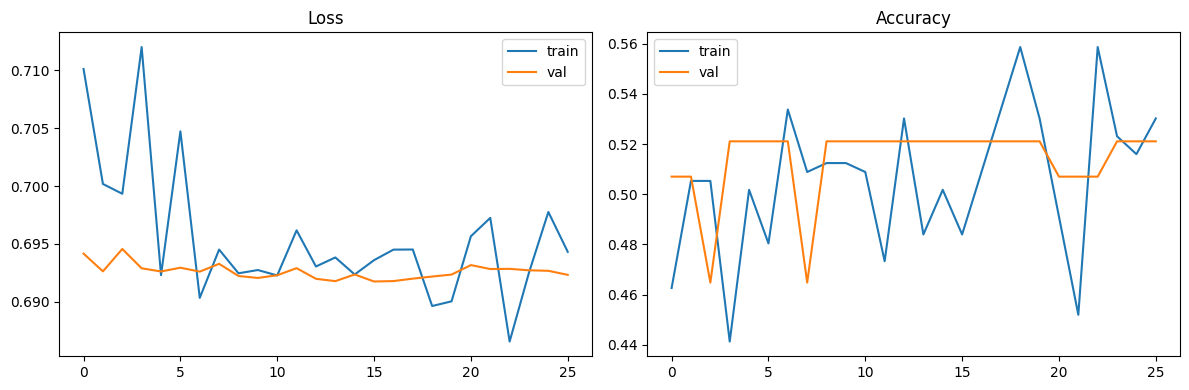

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Model Comparison

In [15]:
summary = pd.DataFrame({
    'Model':     ['Logistic Regression', 'Random Forest', 'LSTM'],
    'Accuracy':  [lr_acc,  rf_acc,  lstm_acc],
    'Precision': [lr_prec, rf_prec, lstm_prec],
    'Recall':    [lr_rec,  rf_rec,  lstm_rec],
})
print(summary.to_string(index=False))

os.makedirs(RESULTS_PATH, exist_ok=True)
summary.to_csv(os.path.join(RESULTS_PATH, 'model_comparison.csv'), index=False)
print("\nSaved to", RESULTS_PATH)

              Model  Accuracy  Precision   Recall
Logistic Regression  0.648936   0.682927 0.583333
      Random Forest  0.659574   0.690476 0.604167
               LSTM  0.477273   0.000000 0.000000

Saved to ../results
